In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/winequalityN - winequalityN.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6488 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6491 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6489 non-null   float64
 9   pH                    6487 non-null   float64
 10  sulphates             6492 non-null   float64
 11  alcohol               6496 non-null   float64
 12  quality               6495 non-null   float64
dtypes: float64(12), object(1)
memory usage: 660.0+ KB


In [ ]:
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6.0
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6.0
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6.0
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6.0
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5.0
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6.0
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6.0
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5.0


In [ ]:
df.describe(include='all')

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497,6487.000000,6488.000000,6494.000000,6491.000000,6495.000000,6497.000000,6497.000000,6489.000000,6487.000000,6492.000000,6496.000000,6495.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,white,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,7.216579,0.339708,0.318722,5.441920,0.056042,30.525319,115.744574,0.994700,3.218364,0.531223,10.491476,5.818938
std,NaN,1.296750,0.164656,0.145265,4.754556,0.035036,17.749400,56.521855,0.002998,0.160741,0.148824,1.192517,0.872806
min,NaN,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,NaN,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992350,3.110000,0.430000,9.500000,5.000000
50%,NaN,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,NaN,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000


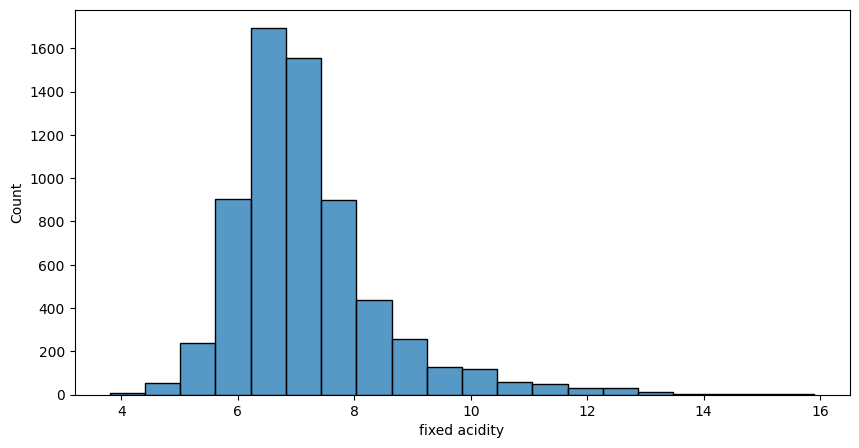

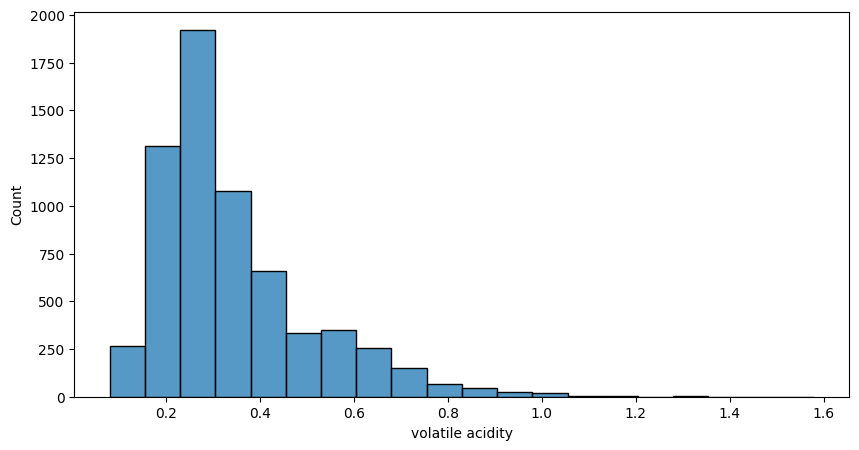

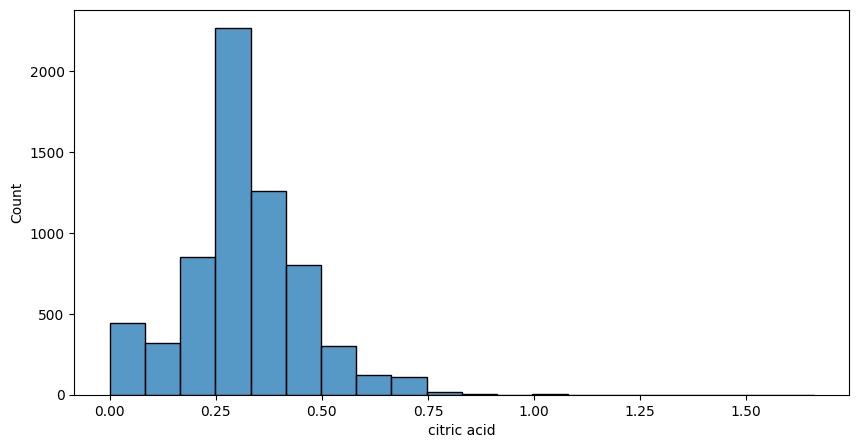

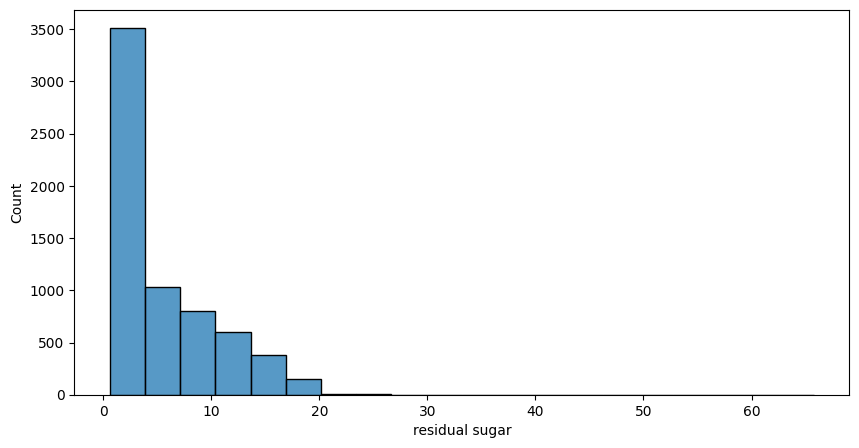

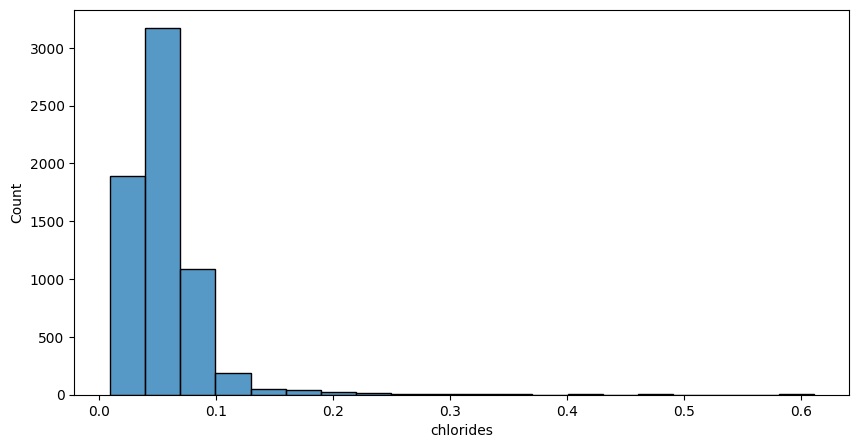

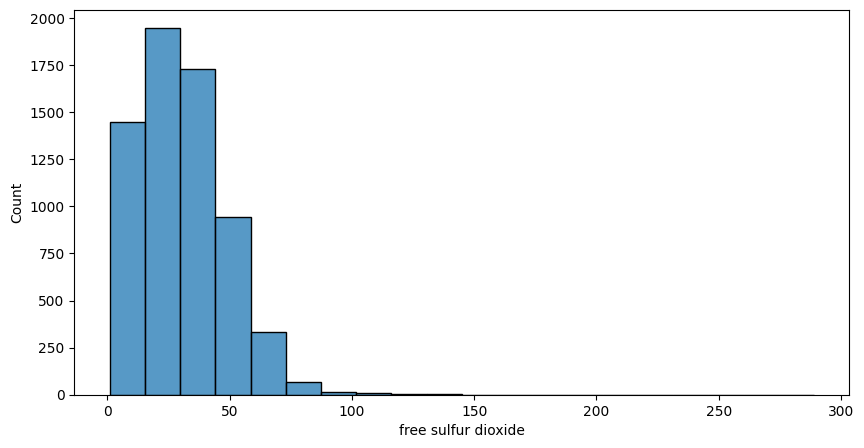

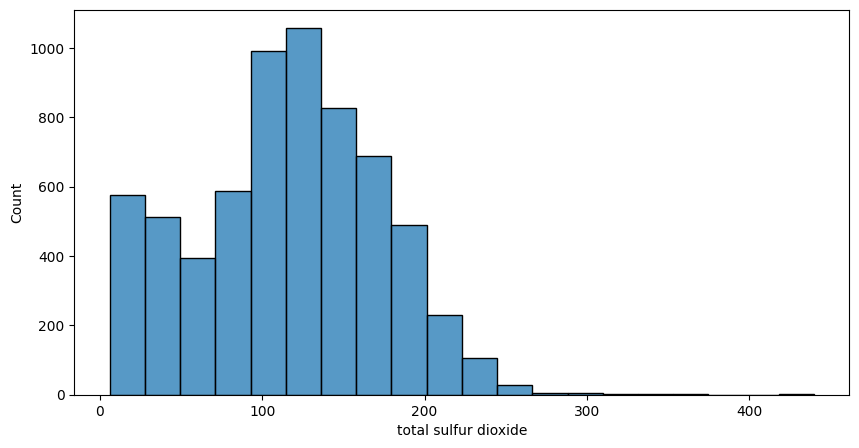

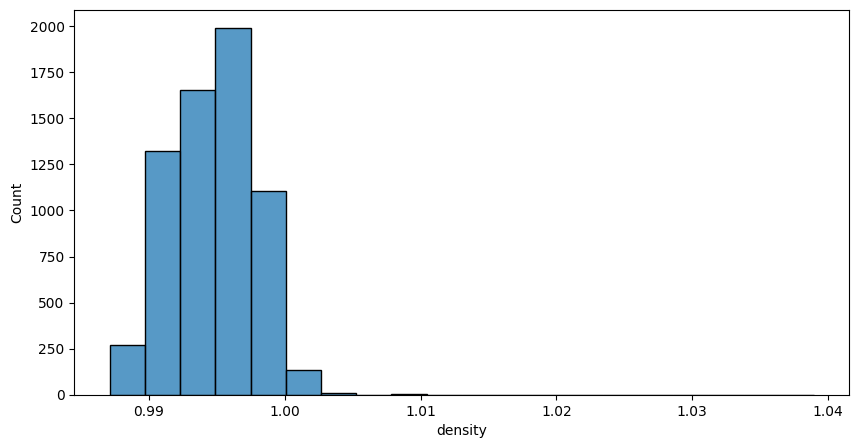

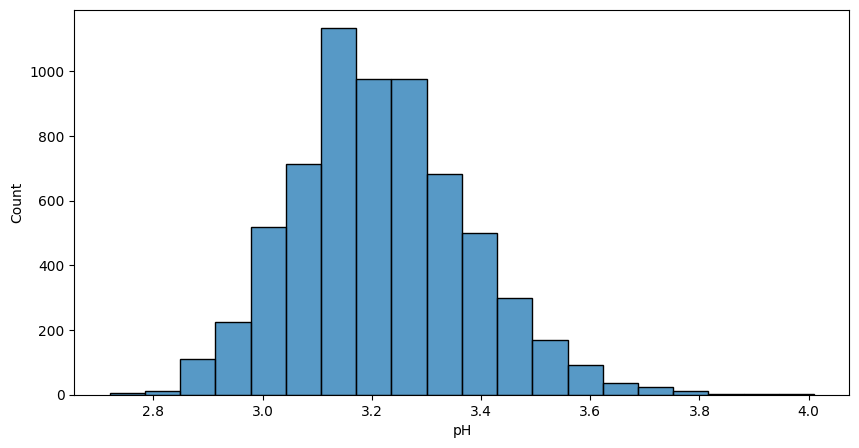

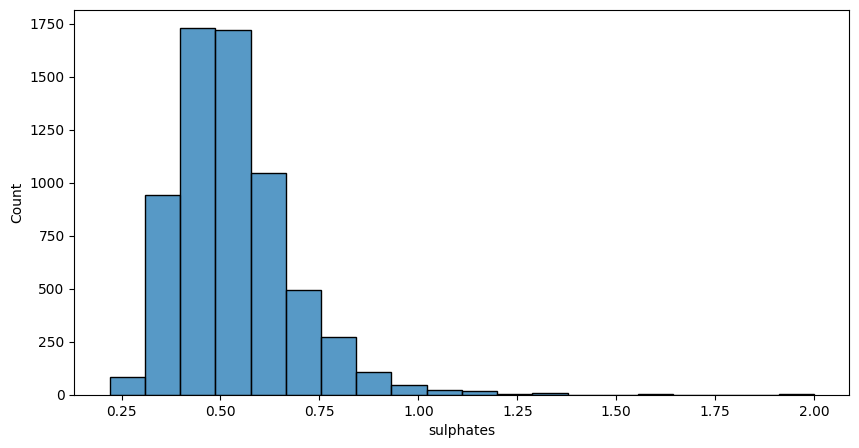

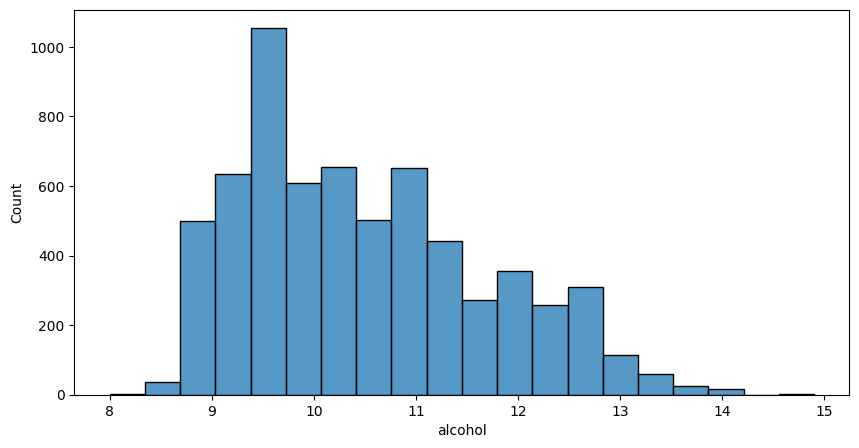

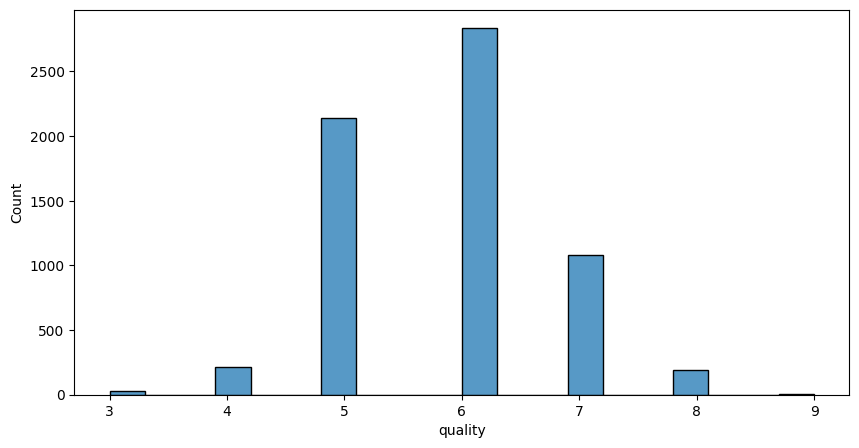

In [ ]:
for col in df.select_dtypes(include=['int','float64']).columns:
    plt.figure(figsize=(10,5))
    sns.histplot(x=df[col],bins=20)
    plt.show()

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

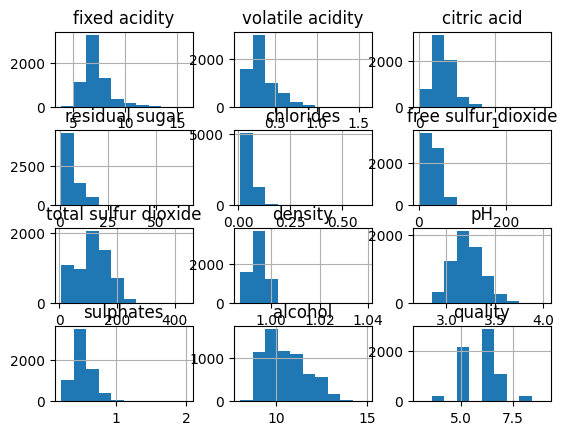

In [ ]:
df.hist()

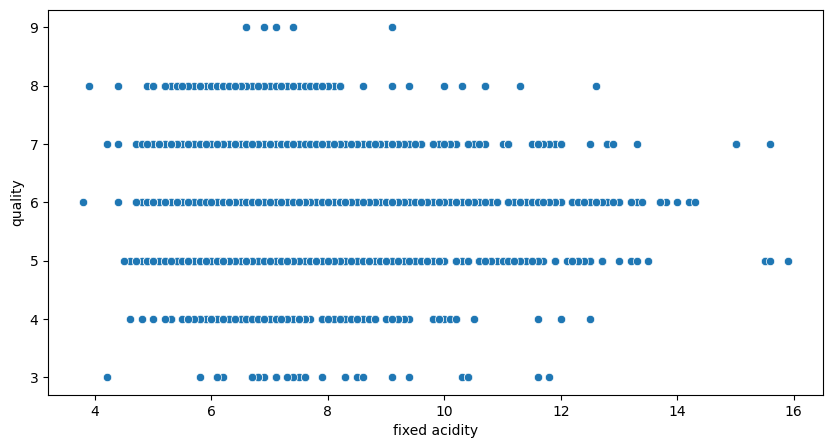

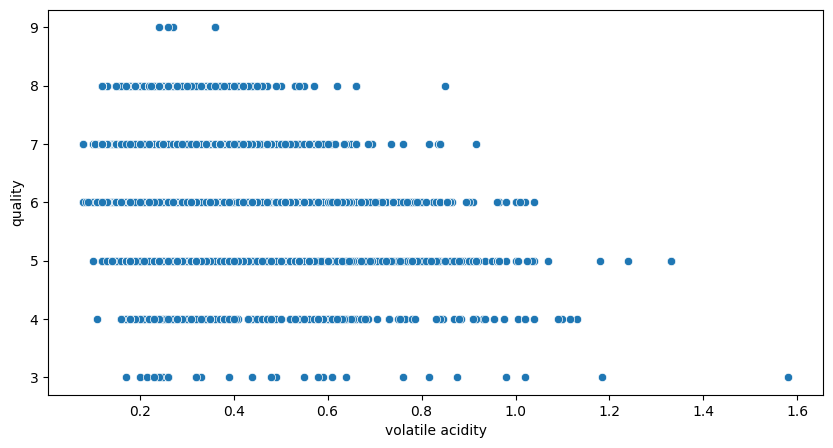

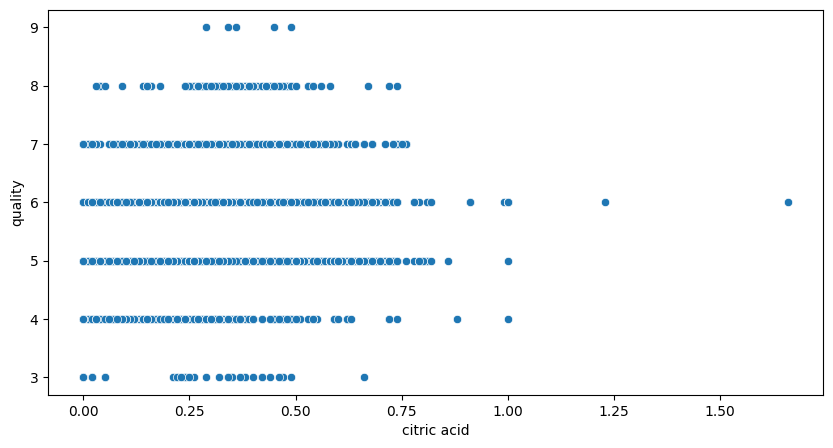

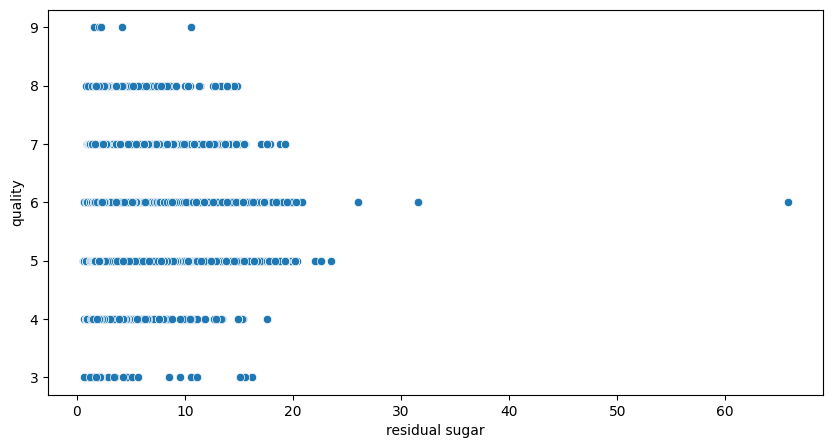

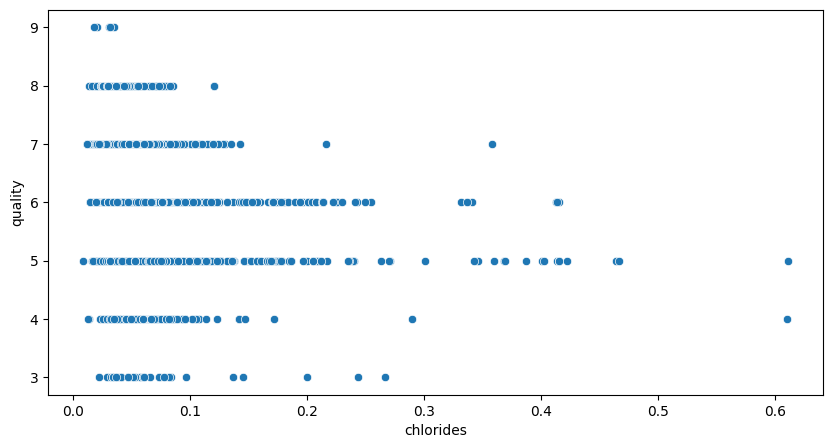

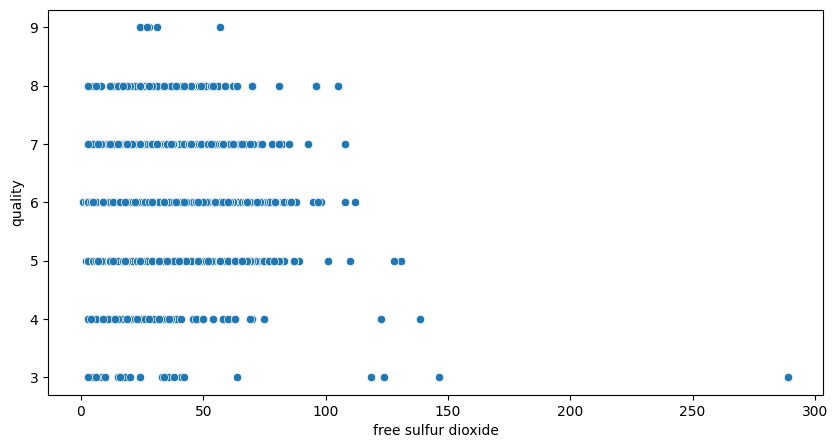

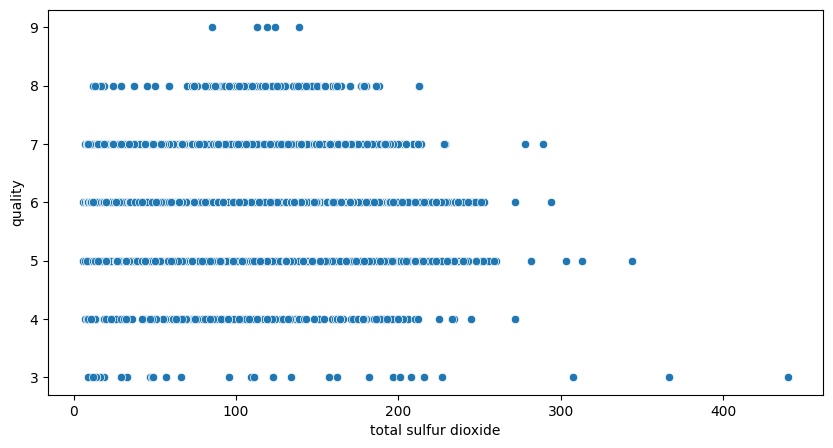

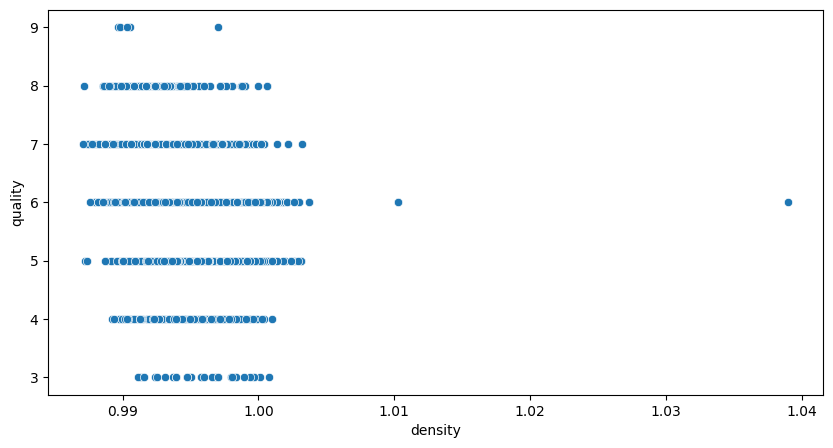

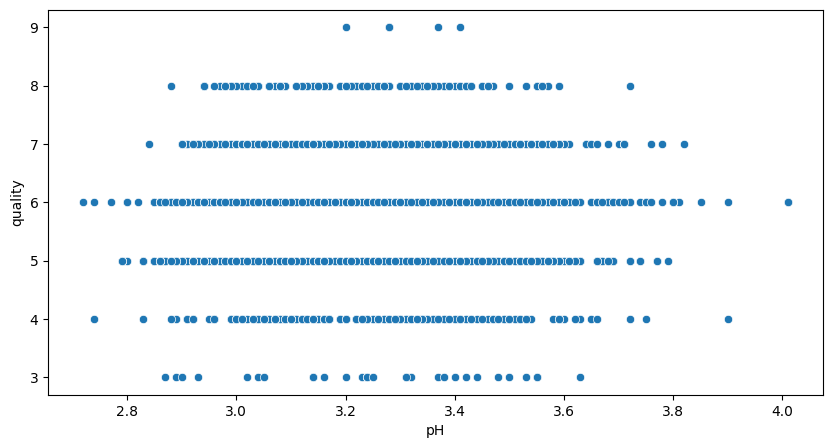

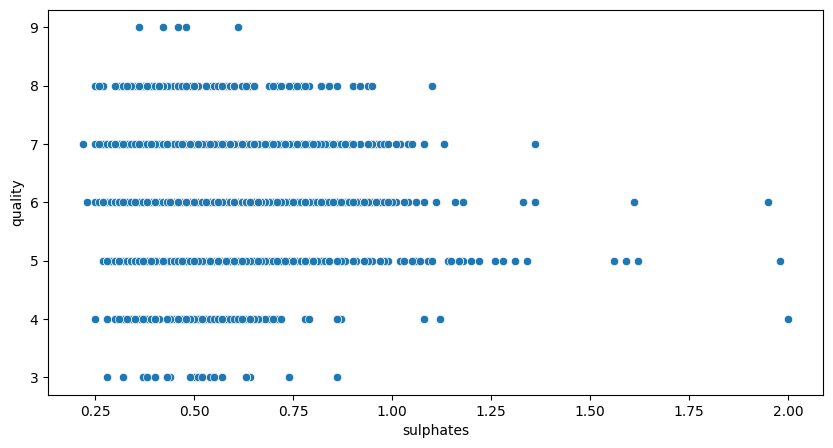

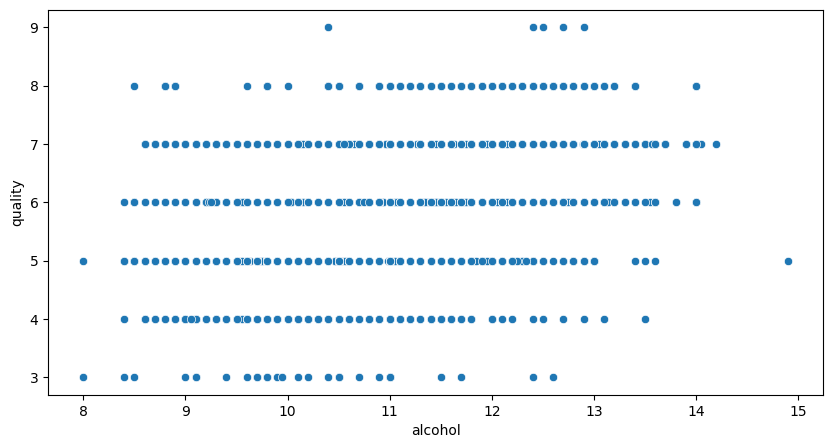

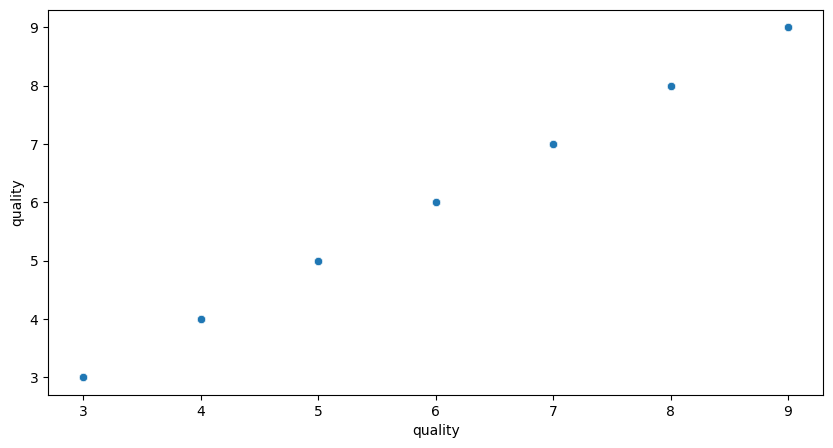

In [ ]:
for col in df.select_dtypes(include=['int','float64']).columns:
    plt.figure(figsize=(10,5))
    sns.scatterplot(x=df[col],y=df['quality'])
    plt.show()

Features with outliers: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


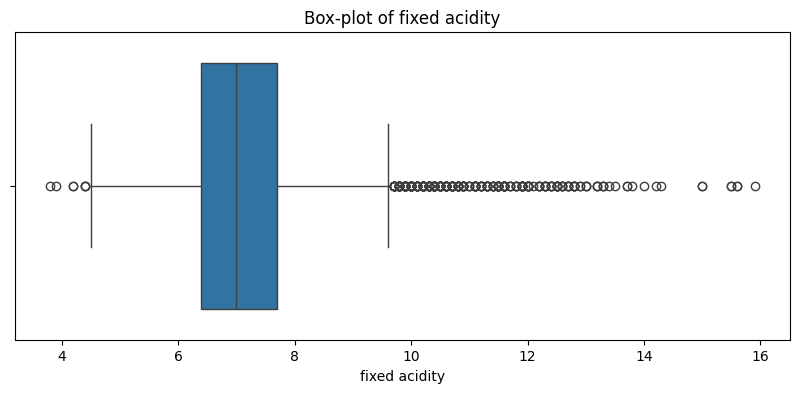

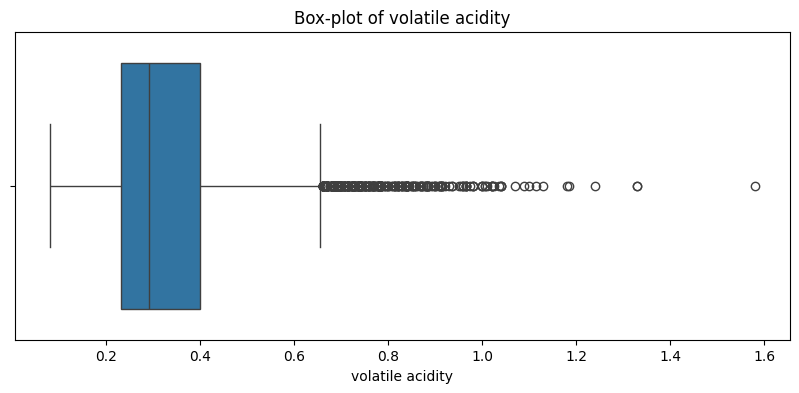

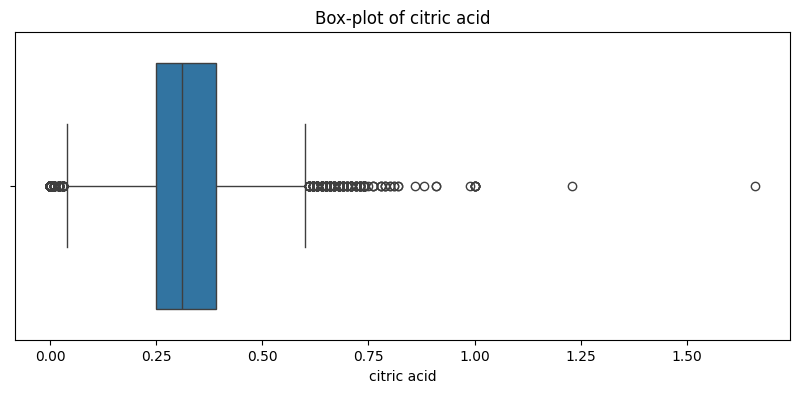

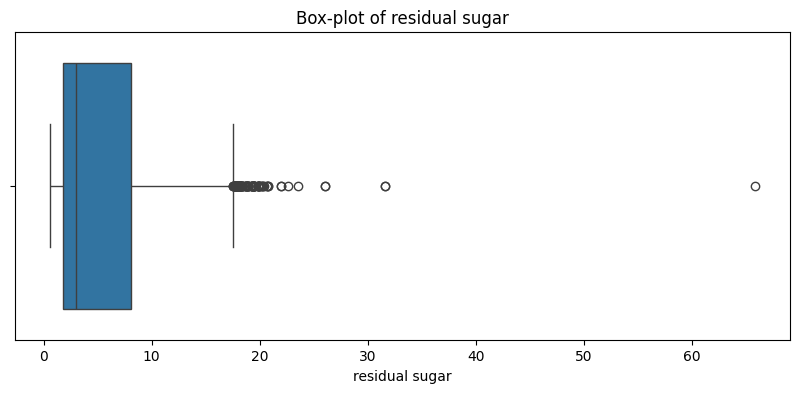

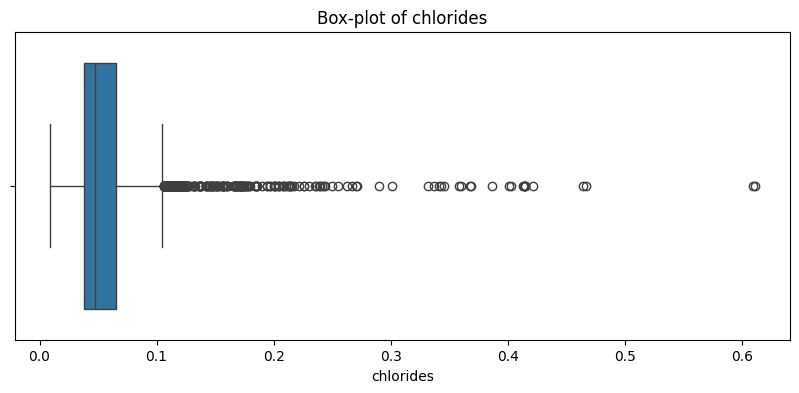

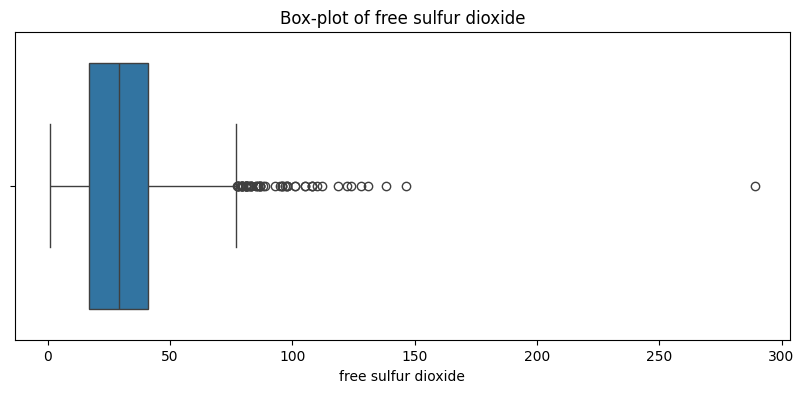

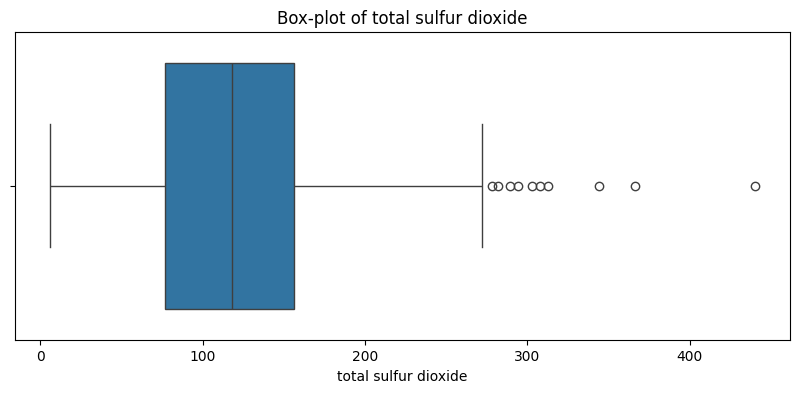

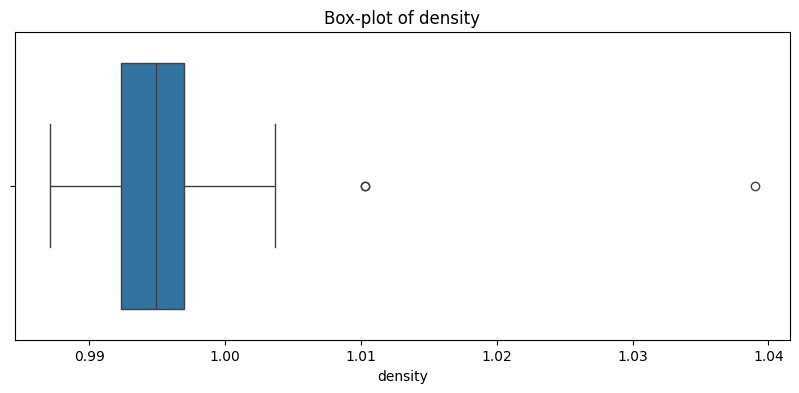

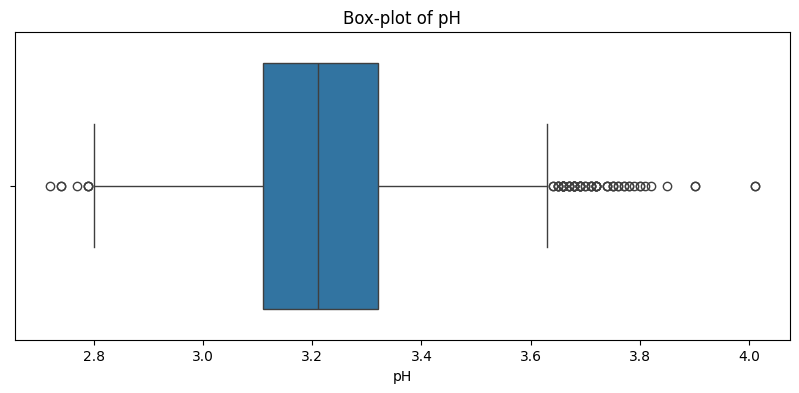

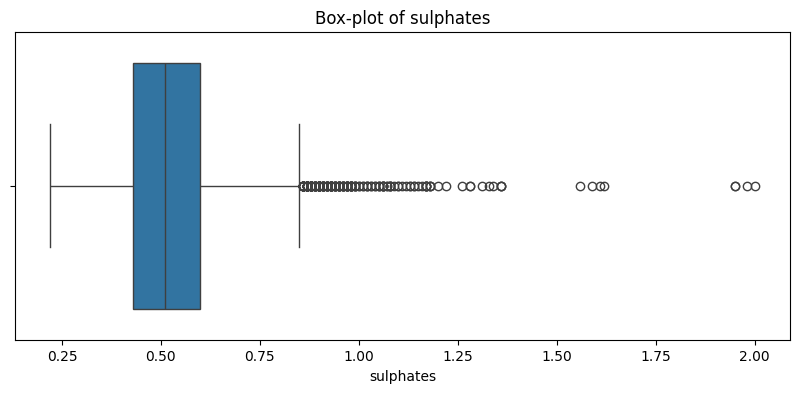

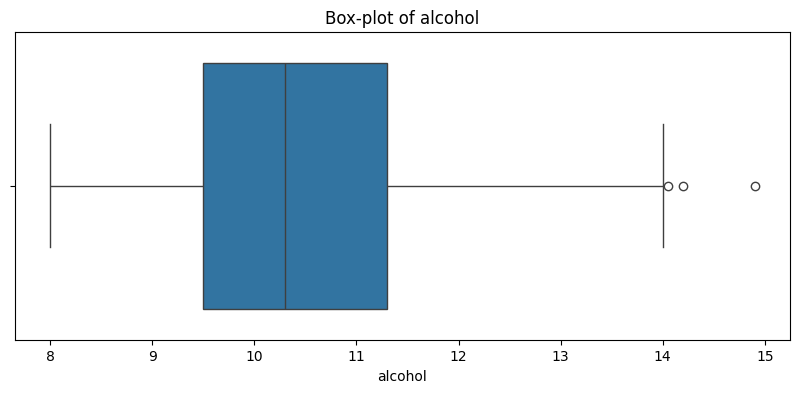

In [ ]:
# 1. Select numerical columns
numerical_cols = df.select_dtypes(include='number').columns
features_with_outliers = []

# 2. Detect Outliers using IQR Method
for col in numerical_cols:
    # Skip 'quality' column from outlier detection as it's the target variable
    if col == 'quality':
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Check if any outliers exist in the column
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        features_with_outliers.append(col)

print("Features with outliers:", features_with_outliers)

# 3. Visualize Boxplots
for col in features_with_outliers:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box-plot of {col}')
    plt.show()

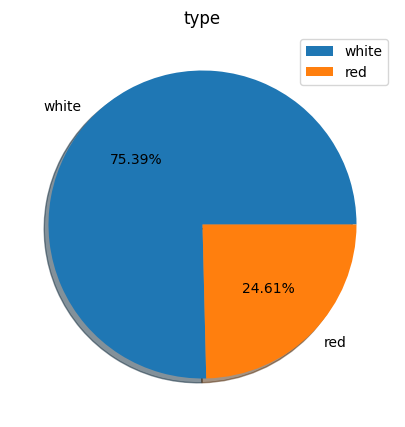

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    if(len(df[col].value_counts().index)<=4):
        plt.figure(figsize=(6,5))
        plt.pie(df[col].value_counts().values,labels=df[col].value_counts().index,shadow=True,autopct='%1.2f%%')
        plt.legend()
        plt.title(f'{col}')
        plt.show()

Features with outliers: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


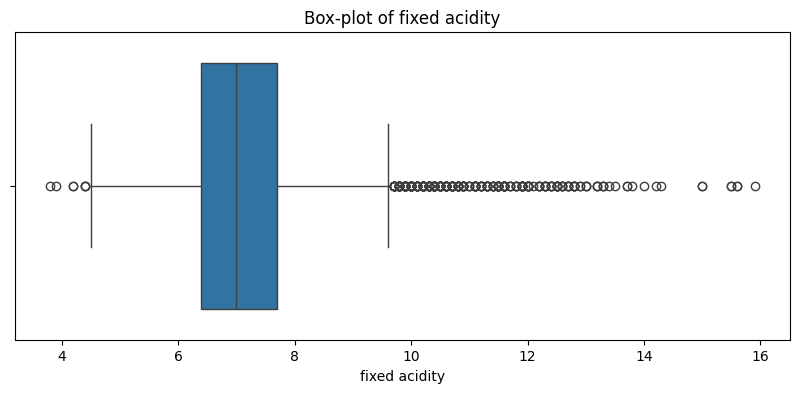

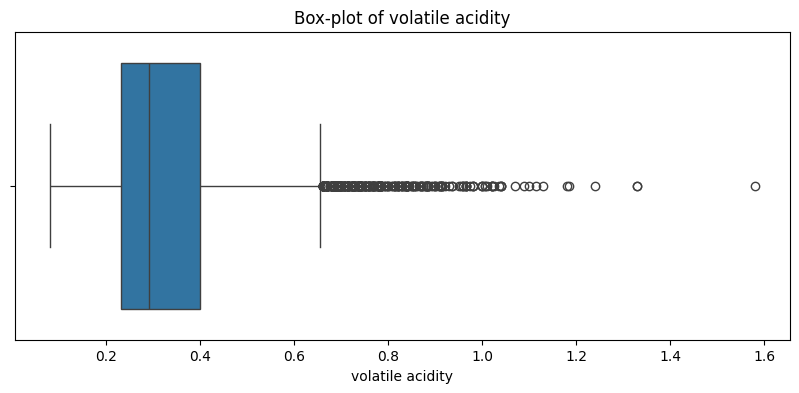

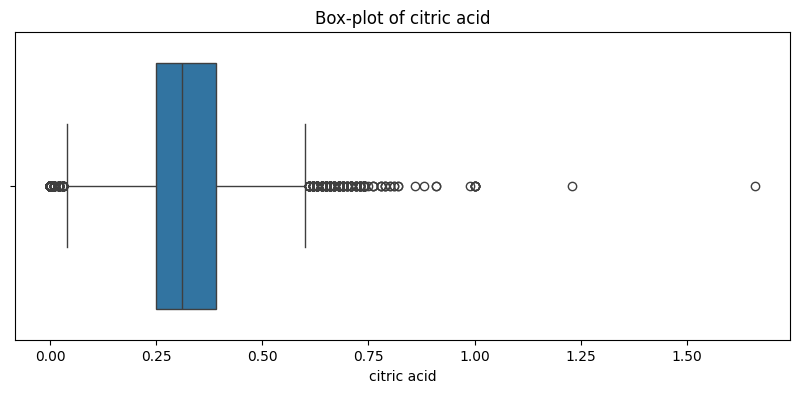

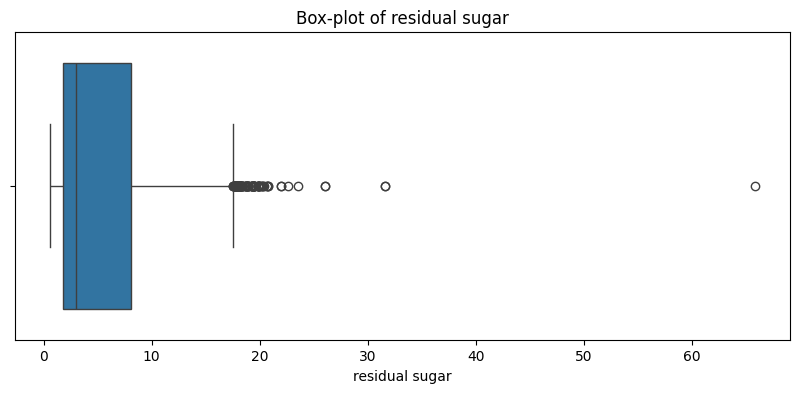

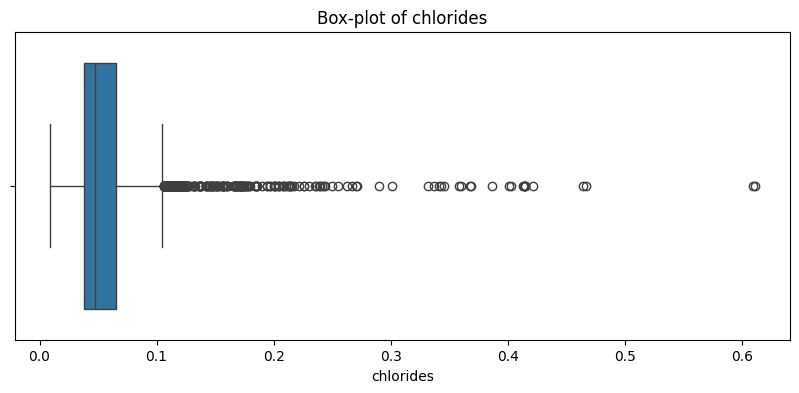

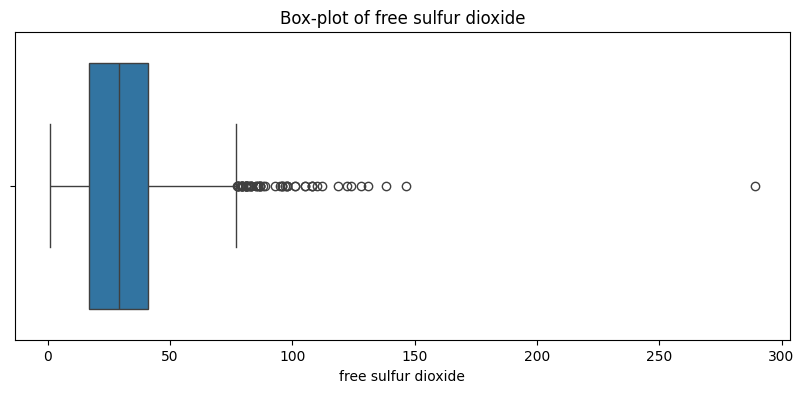

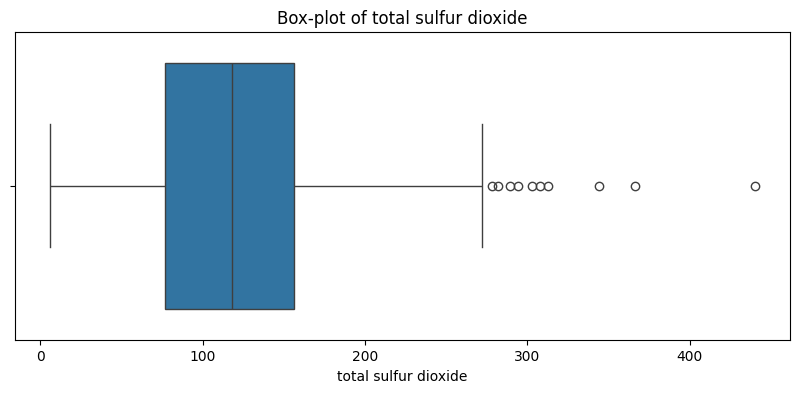

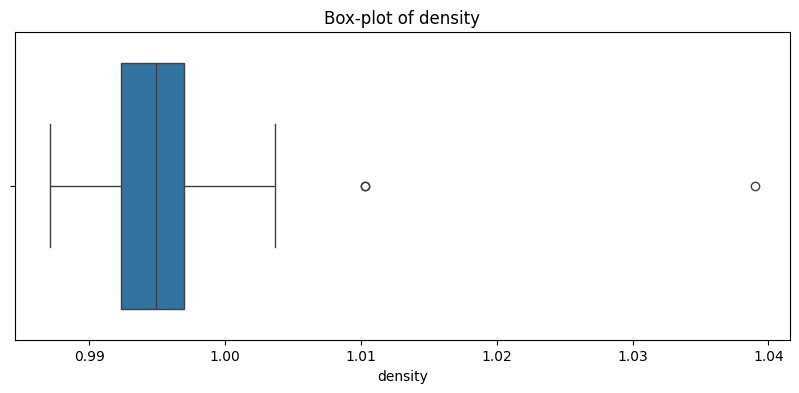

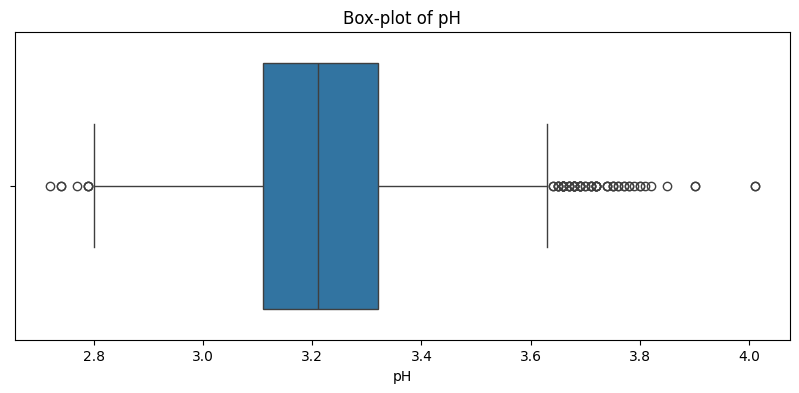

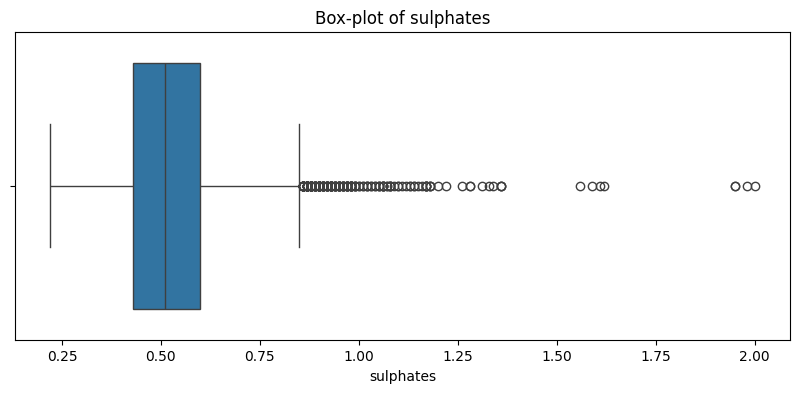

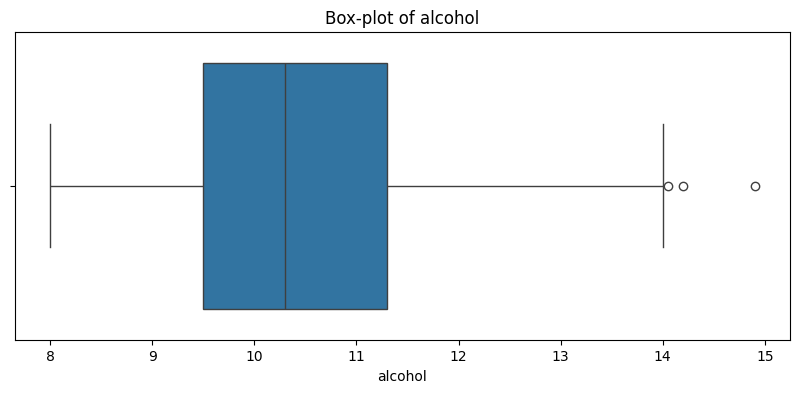

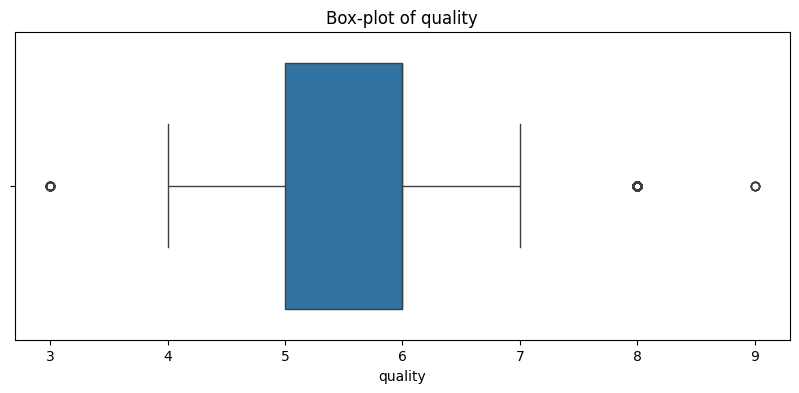

In [ ]:
# 1. Select numerical columns
numerical_cols = df.select_dtypes(include='number').columns
features_with_outliers = []

# 2. Detect Outliers using IQR Method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Check if any outliers exist in the column
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        features_with_outliers.append(col)

print("Features with outliers:", features_with_outliers)

# 3. Visualize Boxplots
for col in features_with_outliers:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box-plot of {col}')
    plt.show()

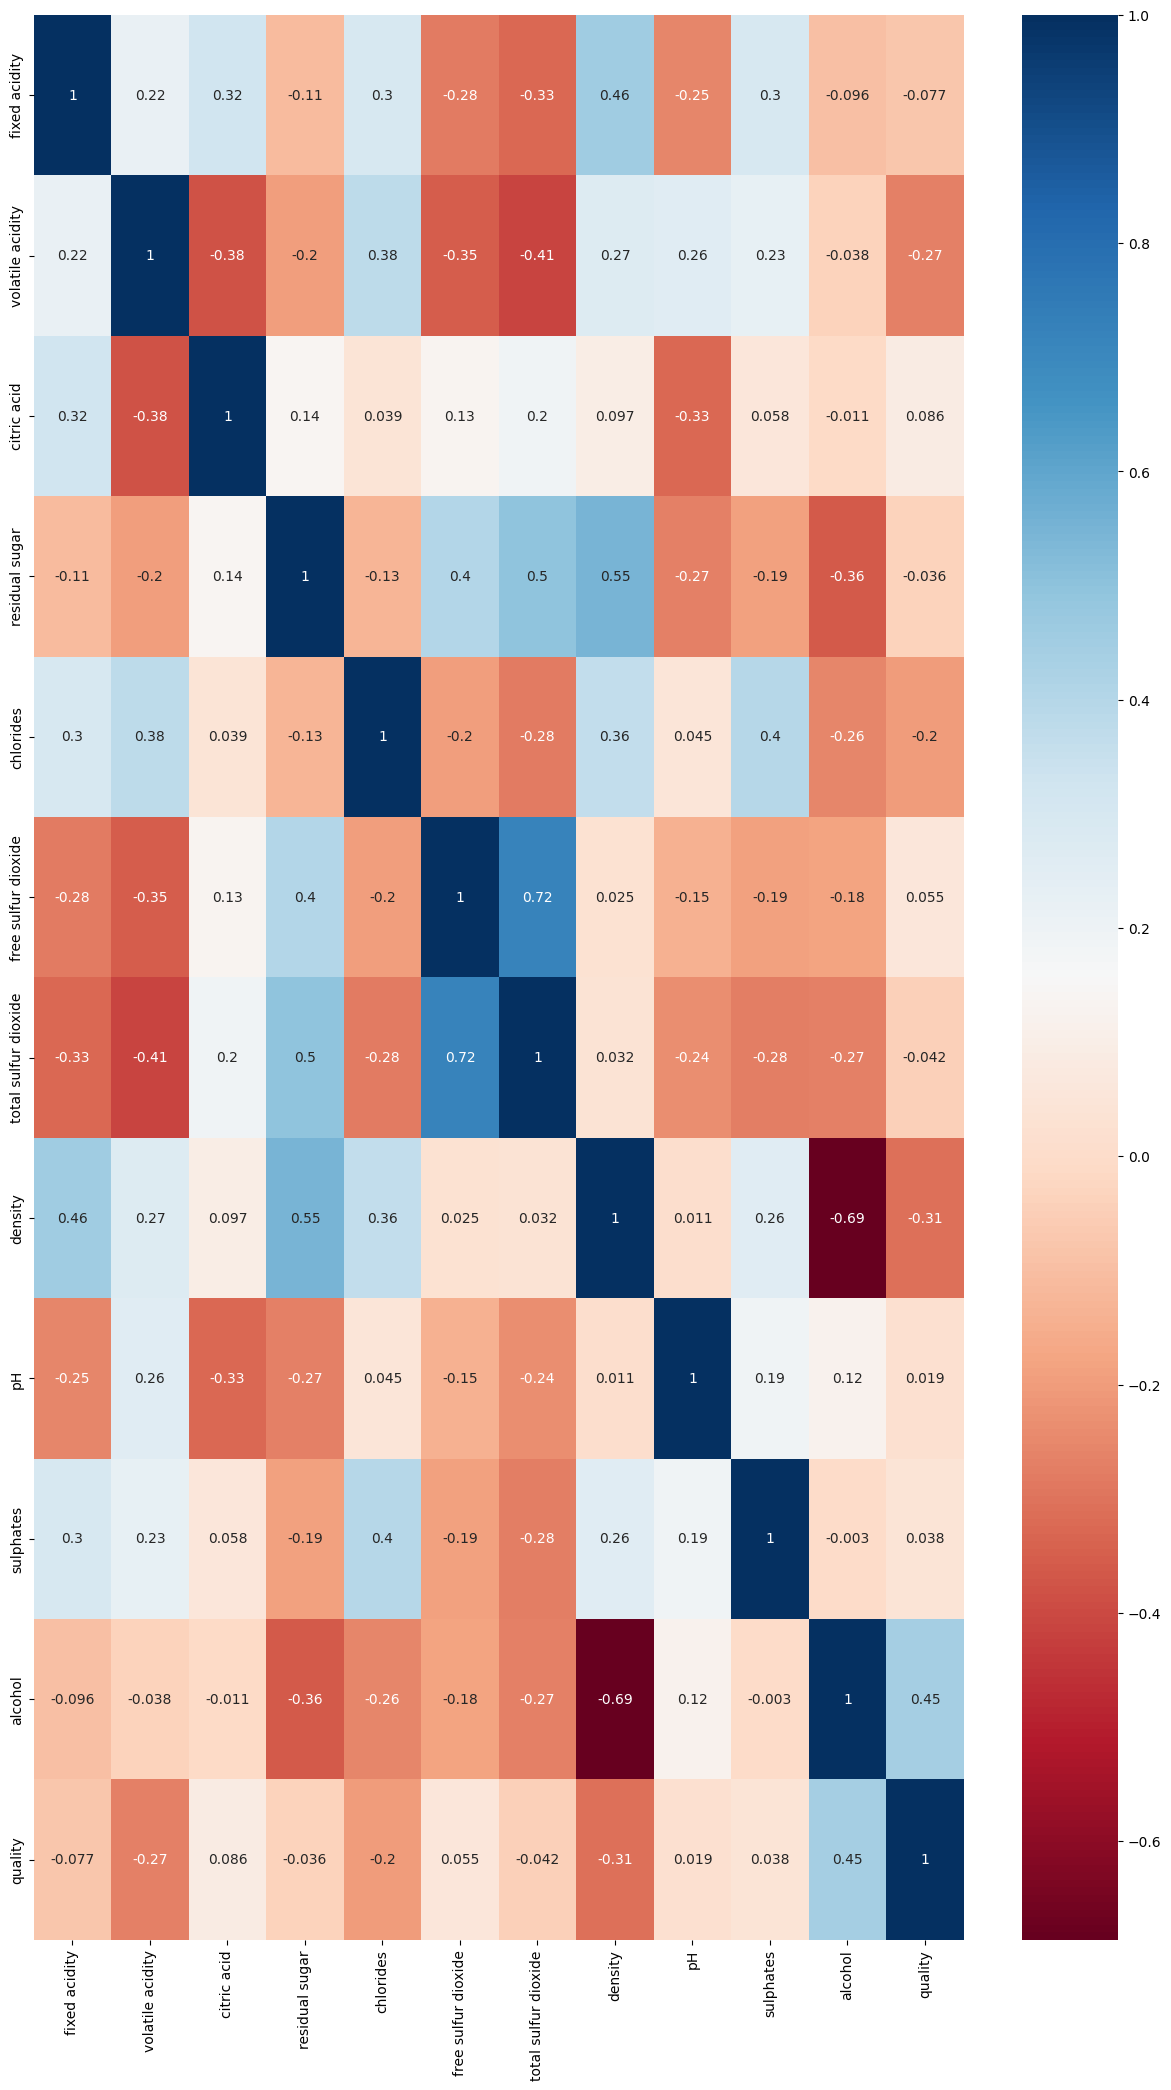

In [ ]:
fig, ax=plt.subplots(figsize=(15,25))
sns.heatmap(df.corr(numeric_only=True ),annot=True,cmap="RdBu")
plt.show()

In [ ]:
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6.0
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6.0
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6.0
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6.0
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5.0
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6.0
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6.0
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5.0


In [ ]:
df.drop(columns=['density'])

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,3.00,0.45,8.8,6.0
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,3.30,0.49,9.5,6.0
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,3.26,0.44,10.1,6.0
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,3.19,0.40,9.9,6.0
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,3.19,0.40,9.9,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,3.45,0.58,10.5,5.0
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,3.52,NaN,11.2,6.0
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,3.42,0.75,11.0,6.0
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,3.57,0.71,10.2,5.0


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
df.corr()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
type,1.000000,-0.487241,-0.652855,0.187126,0.349115,-0.512622,0.471644,0.700357,-0.390321,-0.328885,-0.486903,0.032823,0.119776
fixed acidity,-0.487241,1.000000,0.220309,0.323736,-0.112517,0.298421,-0.283317,-0.329747,0.459705,-0.251757,0.300368,-0.095623,-0.076992
volatile acidity,-0.652855,0.220309,1.000000,-0.378026,-0.197061,0.377129,-0.353337,-0.414955,0.271163,0.260740,0.225463,-0.038296,-0.266034
citric acid,0.187126,0.323736,-0.378026,1.000000,0.142049,0.039315,0.133437,0.195218,0.096874,-0.328861,0.057653,-0.010720,0.086218
residual sugar,0.349115,-0.112517,-0.197061,0.142049,1.000000,-0.128821,0.403876,0.495697,0.551786,-0.267078,-0.186266,-0.359618,-0.036350
chlorides,-0.512622,0.298421,0.377129,0.039315,-0.128821,1.000000,-0.195042,-0.279580,0.362543,0.044834,0.395327,-0.256831,-0.201312
free sulfur dioxide,0.471644,-0.283317,-0.353337,0.133437,0.403876,-0.195042,1.000000,0.720934,0.025424,-0.145057,-0.188465,-0.179711,0.054823
total sulfur dioxide,0.700357,-0.329747,-0.414955,0.195218,0.495697,-0.279580,0.720934,1.000000,0.032304,-0.237809,-0.275378,-0.265576,-0.041793
density,-0.390321,0.459705,0.271163,0.096874,0.551786,0.362543,0.025424,0.032304,1.000000,0.011167,0.259653,-0.686446,-0.307243
pH,-0.328885,-0.251757,0.260740,-0.328861,-0.267078,0.044834,-0.145057,-0.237809,0.011167,1.000000,0.191475,0.121459,0.018592


In [ ]:
df.drop(axis=1,columns=["pH"])

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,0.45,8.8,6.0
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,0.49,9.5,6.0
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,0.44,10.1,6.0
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,0.40,9.9,6.0
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,0.40,9.9,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,0.58,10.5,5.0
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,NaN,11.2,6.0
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,0.75,11.0,6.0
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,0.71,10.2,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   int64  
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6488 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6491 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6489 non-null   float64
 9   pH                    6487 non-null   float64
 10  sulphates             6492 non-null   float64
 11  alcohol               6496 non-null   float64
 12  quality               6495 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 660.0 KB


In [ ]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [ ]:
for col in df.columns:
    if df[col].dtype in ['float64', 'int64', 'int32']:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
from sklearn.model_selection import train_test_split
y=df['quality']
x=df.drop('quality',axis=1)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1,stratify=y) #stratify make it more consistent

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
print(df['quality'].isnull().sum())

0


In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    C=0.01,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
)

In [ ]:
from sklearn import metrics
cnf_matrix=metrics.confusion_matrix(y_test,y_pred)
cnf_matrix

array([[751, 293],
       [ 60, 196]])

In [ ]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7284615384615385


In [ ]:
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,0
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,0
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,0
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.51,11.2,0
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.8193199822314355


In [ ]:
from sklearn.metrics import accuracy_score

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(x_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.8184615384615385
